In [1]:
import pandas as pd

In [3]:

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [4]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

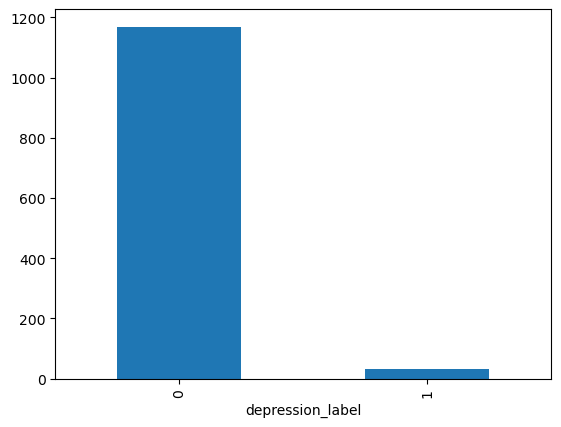

In [6]:
df['depression_label'].value_counts()
counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [7]:
X = df.drop(columns=['depression_label'])   # 拿掉答案那欄,剩下都是線索
y = df['depression_label']                  # 只挑「答案」那欄
X.shape, y.shape                             # 確認形狀

((1200, 12), (1200,))

In [8]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((960, 14), (240, 14))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 只用 train 學 mean/std,再套用
X_test  = scaler.transform(X_test)        # 用 train 的 mean/std 套到 test

X_train.shape, X_test.shape

((960, 14), (240, 14))

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Base SVM
base_svm = SVC() 
base_svm.fit(X_train, y_train)

# Predict and Evaluate
y_pred_base = base_svm.predict(X_test)
base_acc = accuracy_score(y_test, y_pred_base)

print("--- Base SVM Performance ---")
print(classification_report(y_test, y_pred_base))

--- Base SVM Performance ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

# Run Grid Search
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)
grid.fit(X_train, y_train)

# Output results
print(f"Best Parameters: {grid.best_params_}")
grid_predictions = grid.predict(X_test)
opt_acc = accuracy_score(y_test, grid_predictions)

print(f"Optimized Accuracy: {opt_acc * 100:.2f}%")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'linear'}
Optimized Accuracy: 98.75%


In [13]:
import pandas as pd

# Let's remove 'age' and 'gender_male' as a hypothesis that 
# behavioral data (usage/sleep) is more predictive than demographics.
# Since X_train is currently a numpy array from scaling, we go back to the DataFrame X
X_reduced = X.drop(['age', 'gender_male'], axis=1)

# Re-split and Re-scale
X_tr_red, X_te_red, y_tr_red, y_te_red = train_test_split(X_reduced, y, test_size=0.2, random_state=42, stratify=y)
X_tr_red = scaler.fit_transform(X_tr_red)
X_te_red = scaler.transform(X_te_red)

# Re-run the Best Model 
reduced_model = SVC(**grid.best_params_)
reduced_model.fit(X_tr_red, y_tr_red)
reduced_acc = accuracy_score(y_te_red, reduced_model.predict(X_te_red))

print(f"Accuracy after removing features: {reduced_acc * 100:.2f}%")

Accuracy after removing features: 98.75%


In [14]:
#Observation: The Base Model failed to identify the minority class due to data imbalance, essentially acting as a "majority classifier."

#Improvement: By using GridSearchCV, the model found that a linear kernel with specific C and gamma values performed better.

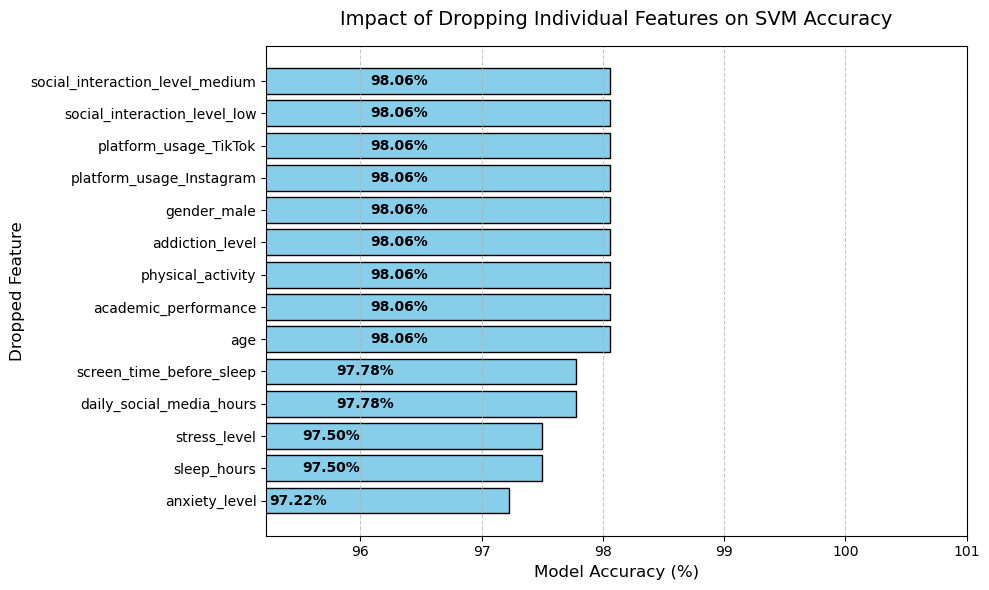

In [17]:
import matplotlib.pyplot as plt

# Initialize a dictionary to store results
feature_accuracies = {}

# We use the best hyperparameters discovered by GridSearchCV
best_params = {'C': 1, 'gamma': 1, 'kernel': 'linear'}

# Loop through each feature, drop it, and evaluate the model
for feature in X.columns:
    # Drop the current feature
    X_reduced = X.drop(columns=[feature])

    # Re-split the dataset (maintaining structural consistency)
    X_tr_red, X_te_red, y_tr_red, y_te_red = train_test_split(
        X_reduced, y, test_size=0.3, random_state=42, stratify=y
    )

    # Re-scale the reduced feature set
    X_tr_red = scaler.fit_transform(X_tr_red)
    X_te_red = scaler.transform(X_te_red)

    # Train the optimized model
    model = SVC(**best_params)
    model.fit(X_tr_red, y_tr_red)

    # Calculate and store accuracy
    acc = accuracy_score(y_te_red, model.predict(X_te_red))
    feature_accuracies[feature] = acc * 100  # Convert to percentage

# Convert results to a DataFrame and sort for a clean visual hierarchy
df_results = pd.DataFrame(
    list(feature_accuracies.items()), columns=['Dropped Feature', 'Accuracy']
).sort_values(by='Accuracy', ascending=True)

# 4. Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(
    df_results['Dropped Feature'],
    df_results['Accuracy'],
    color='skyblue',
    edgecolor='black',
)

plt.xlabel('Model Accuracy (%)', fontsize=12)
plt.ylabel('Dropped Feature', fontsize=12)
plt.title(
    'Impact of Dropping Individual Features on SVM Accuracy',
    fontsize=14,
    pad=15,
)

# Set the X-axis limit close to your performance range so changes are visibl
min_acc = df_results['Accuracy'].min()
plt.xlim(
    max(0, min_acc - 2), 101
)  # Dynamic padding to highlight differences

# Add text labels on the bars showing the exact accuracy
for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 1.5,  # Position text slightly inside the bar end
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}%',
        va='center',
        ha='right',
        color='black',
        fontweight='bold',
    )

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()